# Querying the Knowledge Base

In [1]:
import cytopus as cp
import os

## Loading and exploring KnowledgeBase

In [2]:
G = cp.KnowledgeBase()

KnowledgeBase object containing 92 cell types and 201 cellular processes



In [3]:
#number of cellular identity gene sets
len(G.identities.keys())

53

In [4]:
#get genesets for a specific celltype
query_celltype = 'M'
gs_of_interest = [x[0] for x in G.filter_edges(attribute_name = 'class', attributes = ['process_OF'],target=query_celltype) if x[1]==query_celltype]
print('Gene sets directly related to celltype',query_celltype,'are:',gs_of_interest)

Gene sets directly related to celltype M are: ['M_IL17A_response', 'M_mac_CSF1_response', 'M_angiogenic-effectors']


In [5]:
#list of all cell types in KnowledgeBase
G.celltypes

['CD8-T_terminal-exhaustion',
 'endo-arterial',
 'ILC1',
 'TCM',
 'baso',
 'T-naive',
 'ILC',
 'gran',
 'cDC3',
 'cDC',
 'endo-lymphatic',
 'ILC3-NCRpos',
 'lung-endo-venous',
 'Lti',
 'CD8-TSCM',
 'CD56dim-NK',
 'neutro',
 'lung-smooth-muscle',
 'endo-systemic-venous',
 'crc-carcinoma-cell',
 'p-DC',
 'B-memory-switched',
 'all-cells',
 'colon-epi',
 'ILC3',
 'CD4-TSCM',
 'B-memory-non-switched',
 'iNKT',
 'capillary',
 'CD4-TEM',
 'GC-B',
 'Mac',
 'CD8-TCM',
 'cDC1',
 'B-naive',
 'B-pb-mature',
 'CD8-Teffector',
 'CD8-T-progenitor-exhausted',
 'TSCM',
 'fibro',
 'endo',
 'T',
 'DC',
 'NSCLC-carcinoma-cell',
 'B-pb-t2',
 'B-memory',
 'MAIT',
 'plasma-blast',
 'mono',
 'Treg',
 'MDC',
 'CD8-TEM',
 'M',
 'eosino',
 'NK-adaptive',
 'B-memory-IgM-MZ',
 'TFH',
 'carcinoma-cell',
 'CD8-T_KLRG1pos-effector',
 'abT',
 'c-mono',
 'CD4-T',
 'leukocyte',
 'gdT',
 'B',
 'TEM',
 'ILC3-NCRneg',
 'TRM',
 'CD4-TRM',
 'CD8-TRM',
 'B-memory-DN',
 'endo-aerocyte',
 'B-pb-t3',
 'TNK',
 'cDC2',
 'mast',
 

all celltypes in knowledge base: ['CD8-T_terminal-exhaustion', 'endo-arterial', 'ILC1', 'TCM', 'baso', 'T-naive', 'ILC', 'gran', 'cDC3', 'cDC', 'endo-lymphatic', 'ILC3-NCRpos', 'lung-endo-venous', 'Lti', 'CD8-TSCM', 'CD56dim-NK', 'neutro', 'lung-smooth-muscle', 'endo-systemic-venous', 'crc-carcinoma-cell', 'p-DC', 'B-memory-switched', 'all-cells', 'colon-epi', 'ILC3', 'CD4-TSCM', 'B-memory-non-switched', 'iNKT', 'capillary', 'CD4-TEM', 'GC-B', 'Mac', 'CD8-TCM', 'cDC1', 'B-naive', 'B-pb-mature', 'CD8-Teffector', 'CD8-T-progenitor-exhausted', 'TSCM', 'fibro', 'endo', 'T', 'DC', 'NSCLC-carcinoma-cell', 'B-pb-t2', 'B-memory', 'MAIT', 'plasma-blast', 'mono', 'Treg', 'MDC', 'CD8-TEM', 'M', 'eosino', 'NK-adaptive', 'B-memory-IgM-MZ', 'TFH', 'carcinoma-cell', 'CD8-T_KLRG1pos-effector', 'abT', 'c-mono', 'CD4-T', 'leukocyte', 'gdT', 'B', 'TEM', 'ILC3-NCRneg', 'TRM', 'CD4-TRM', 'CD8-TRM', 'B-memory-DN', 'endo-aerocyte', 'B-pb-t3', 'TNK', 'cDC2', 'mast', 'mo-DC', 'CD8-T', 'nc-mono', 'lung-epi', 'L

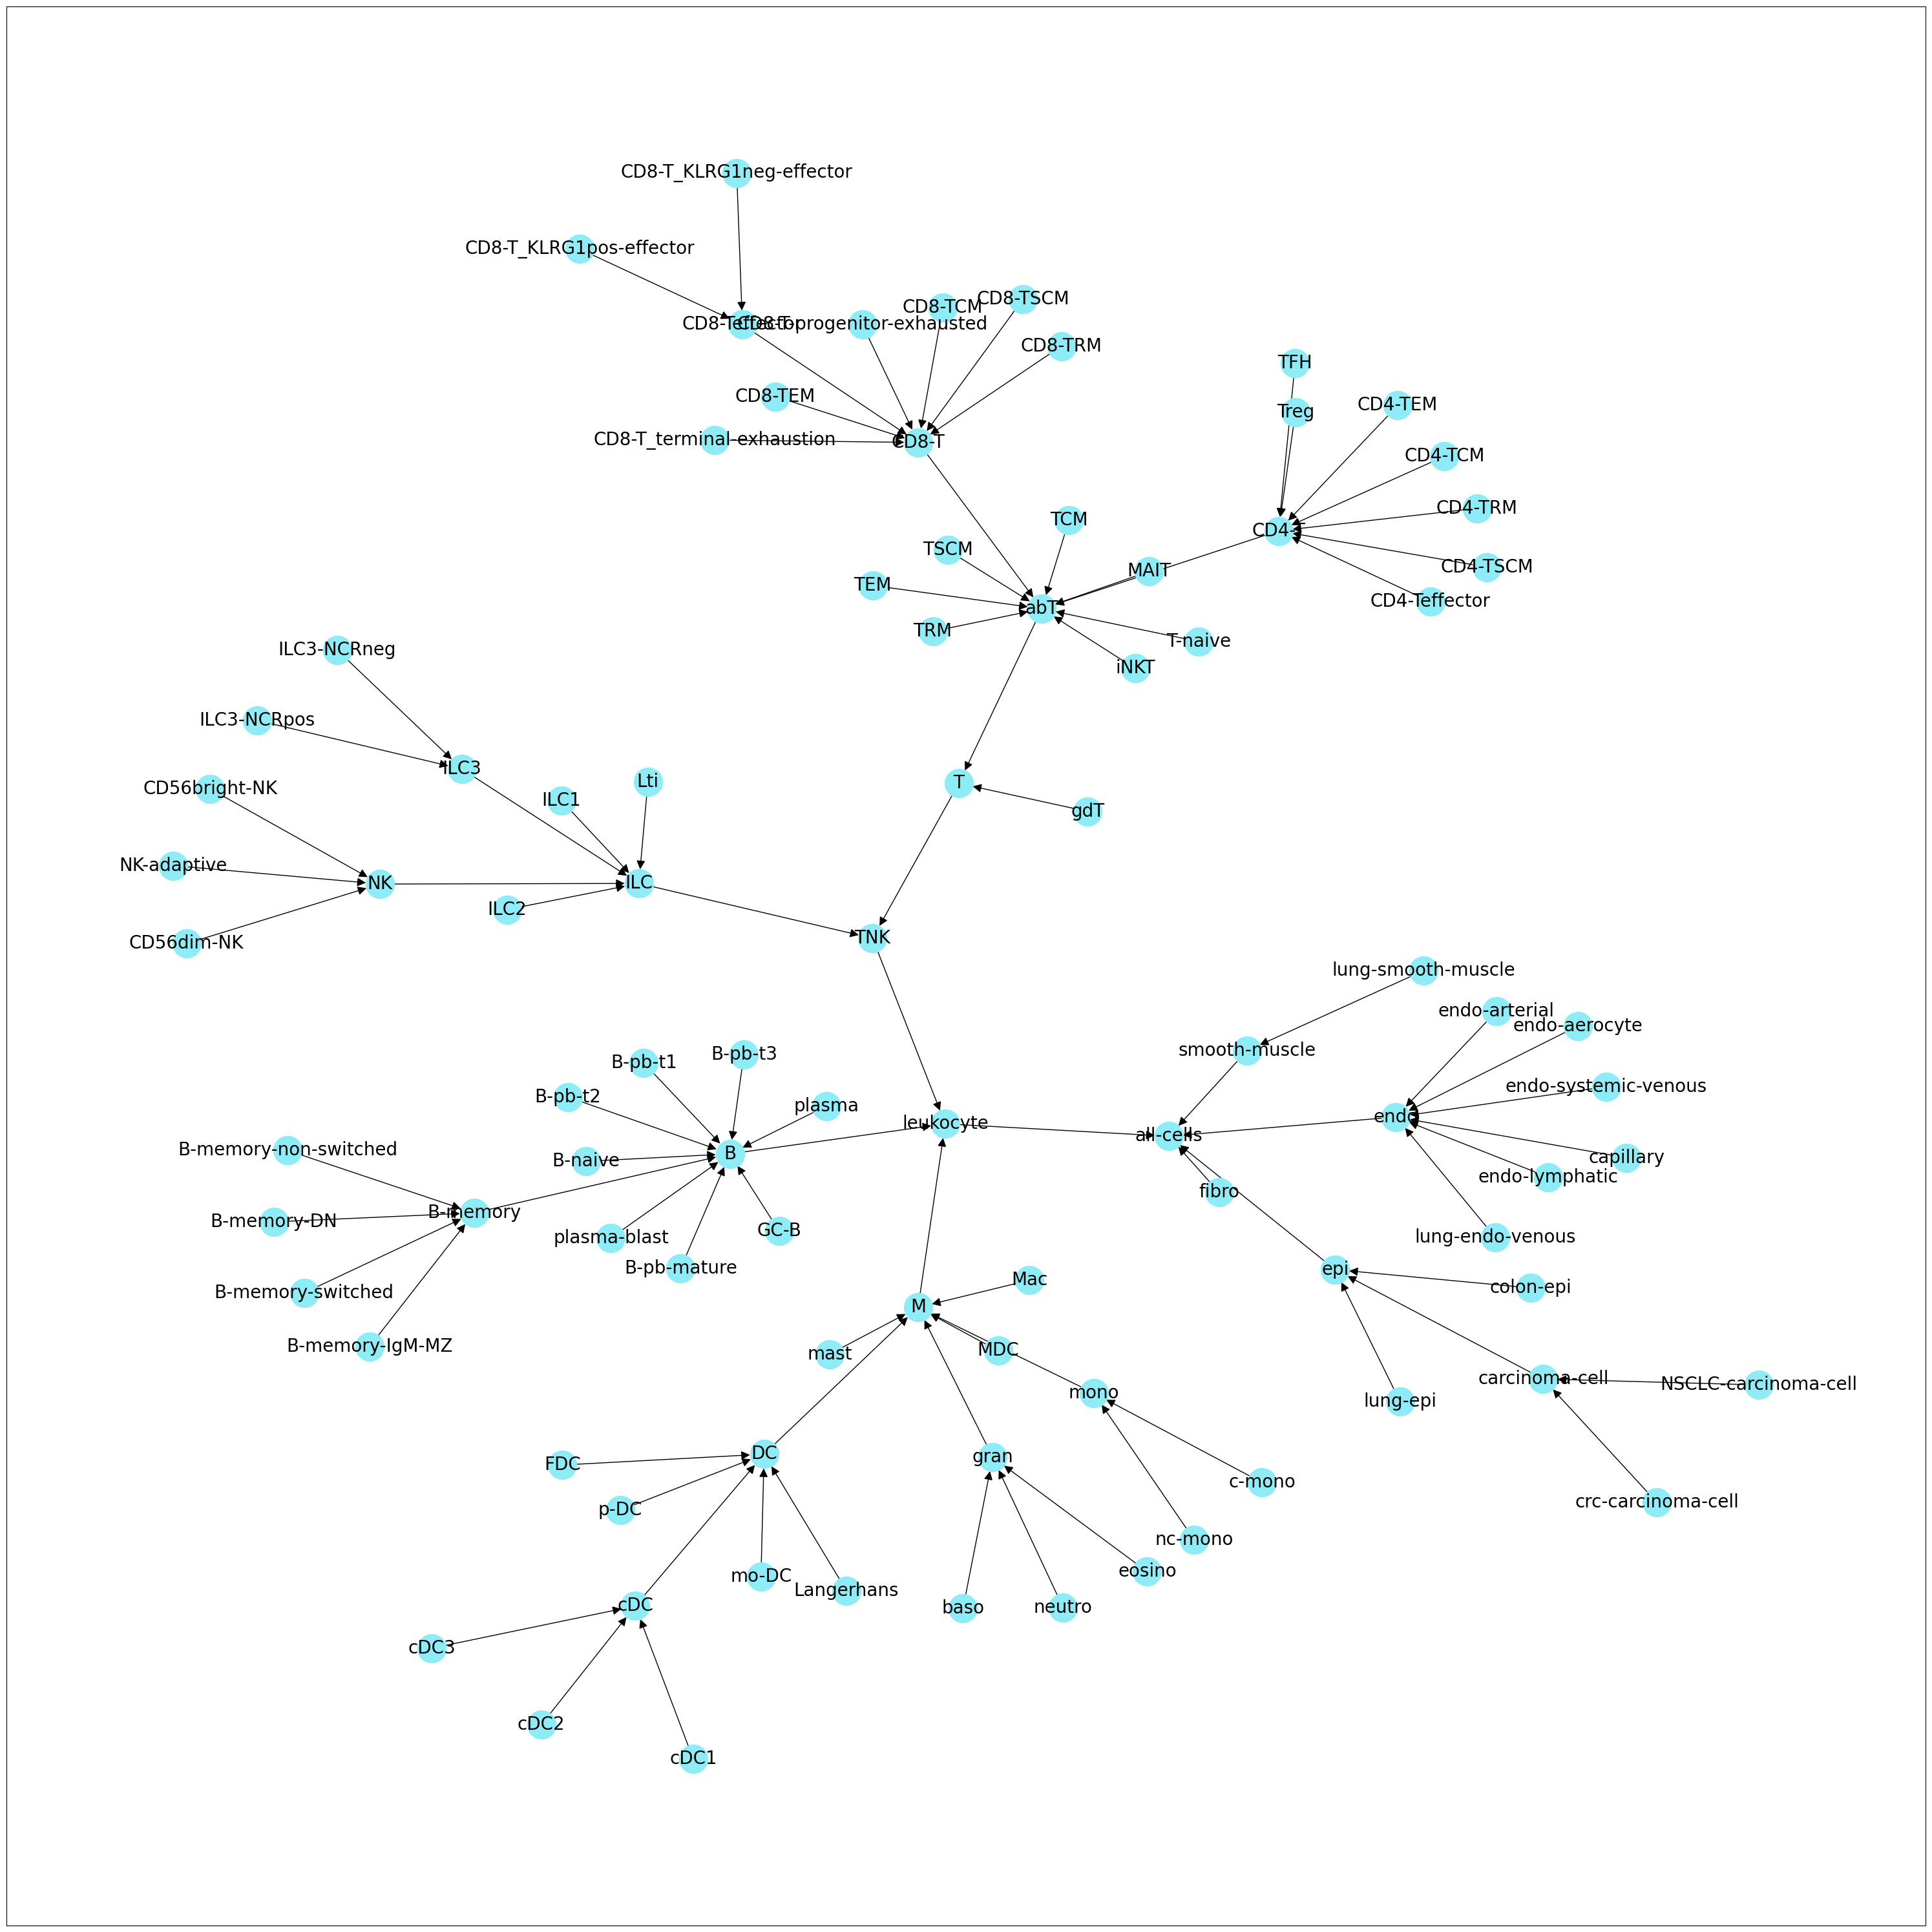

In [6]:
#plot the cell type hierarchy
G.plot_celltypes()

In [7]:
G.plot_graph_interactive(attributes=['cell_type','cellular_process'],colors= ['red','blue'], save_path = 'graph.html')
print(f'Graph saved to "graph.html". Open this file in your browser to view the interactive graph.')

graph.html
Graph saved to "graph.html". Open this file in your browser to view the interactive graph.


In [8]:
#get parent in the hierarchy of specific cell type
list(G.graph.successors('cDC')) #arrows are 'SUBSET_OF' not 'PARENT_OF' --> use successor to get parents

['DC']

In [9]:
#get child in the hierarchy of a specific cell type
list(G.graph.predecessors('cDC')) #arrows are 'SUBSET_OF' not 'PARENT_OF' --> use successor to get parents

['cDC1', 'cDC2', 'cDC3']

In [10]:
#get cell type markers
G.get_identities(['TNK'],include_subsets=True).keys()

dict_keys(['TCM', 'Treg', 'T-naive', 'TSCM', 'ILC1', 'NK-adaptive', 'TEM', 'CD56bright-NK', 'CD8-T_KLRG1pos-effector', 'CD4-T', 'CD56dim-NK', 'TRM', 'Lti', 'ILC3-NCRpos', 'abT', 'TFH', 'CD8-T_KLRG1neg-effector', 'ILC3-NCRneg', 'ILC2', 'gdT', 'NK', 'CD8-T'])

In [11]:
#dictionary of all cellular processes in KnowledgeBase as a dictionary {'process_1':['gene_a','gene_e','gene_y',...],'process_2':['gene_b','gene_u',...],...}
G.processes.keys()

dict_keys(['all_chondroitine-and-heparan-sulfate_synthesis', 'all_retinol_metabolism', 'all_RIG-I-like-receptor_signaling', 'leuko_transendothelial-migration', 'all_propanoate_metabolism', 'NSCLC-carcinoma-cell_TGFB1_response', 'all_p53-signaling', 'all_autophagy-selective', 'all_circadian-rhythm', 'all_VAL-LEU-ILE_metabolism', 'M_IL17A_response', 'all_taurine-hypotaurine_metabolism', 'B_IgM-ligation_response', 'all_microautophagy-lysosomal', 'all_transmembrane-transport-ER', 'all_macroautophagy_regulation_positive', 'all_TYR_metabolism', 'all_SASP', 'all_histone-methylation', 'all_TNF-via-NFkB_signaling', 'all_iron-uptake-and-storage', 'all_n-glycan_synthesis', 'all_transmembrane-transport-golgi', 'all_PHE_metabolism', 'Treg_FoxP3-stabilization', 'all_riboflavin_metabolism', 'all_polyamines_metabolism', 'all_PI3K-AKT-mTOR_signaling', 'all_inositol-phosphate_metabolism', 'all_DNA-demethylation', 'fibro_IL4_response', 'all_wnt-beta-catenin-signaling', 'M_mac_CSF1_response', 'all_lactate

In [12]:
#dictionary of all cellular identities in KnowledgeBase as a dictionary {'identity_1':['gene_j','gene_k','gene_z',...],'identity_2':['gene_y','gene_p',...],...}
G.identities.keys()

dict_keys(['TCM', 'Treg', 'T-naive', 'B-pb-t2', 'endo-lymphatic', 'TSCM', 'cDC1', 'ILC1', 'NK-adaptive', 'TEM', 'FDC', 'endo-systemic-venous', 'endo-aerocyte', 'CD56bright-NK', 'plasma-blast', 'CD8-T_KLRG1pos-effector', 'p-DC', 'mast', 'B-memory-DN', 'B-naive', 'CD4-T', 'B-pb-t3', 'B', 'B-pb-mature', 'Mac', 'gran', 'cDC2', 'CD56dim-NK', 'TRM', 'Lti', 'ILC3-NCRpos', 'abT', 'TFH', 'mono', 'CD8-T_KLRG1neg-effector', 'B-memory-IgM-MZ', 'cDC3', 'B-memory-switched', 'ILC3-NCRneg', 'Langerhans', 'mo-DC', 'endo-arterial', 'ILC2', 'plasma', 'B-pb-t1', 'lung-endo-venous', 'gdT', 'NK', 'capillary', 'CD8-T', 'B-memory', 'B-memory-non-switched', 'GC-B'])

In [13]:
#get genesets for a specific celltype
query_celltype = 'Treg'
gs_of_interest = [x[0] for x in G.filter_edges(attribute_name = 'class', attributes = ['process_OF'],target=query_celltype) if x[1]==query_celltype]
print('Gene sets directly related to celltype',query_celltype,'are:',gs_of_interest)

Gene sets directly related to celltype Treg are: ['Treg_FoxP3-stabilization']


In [14]:
#dictionary with gene set properties (for cellular processes or identities)

print('here external gene set from GO:')
print(G.graph.nodes['all_macroautophagy_regulation_positive'])

print('here manually curated gene set by the package author:')
print(G.graph.nodes['Mac_LPS_response'])

here external gene set from GO:
{'version_id': 'v_hs209', 'author': 'GO Term 2019-01-01: 10.5281/zenodo.2529950_210828, 10.1038/75556,  10.1093/nar/gkaa1113', 'license': ' Creative Commons Attribution 4.0 Unported License', 'license_link': 'http://geneontology.org/docs/go-citation-policy/', 'license_type': 'c', 'gene_set_type': 'manual_external', 'gene_set_topic': 'cell_death_autophagy'}
here manually curated gene set by the package author:
{'version_id': 'v_hs230', 'author': 'wallet', 'license': 'MIT', 'license_link': 'https://github.com/wallet-maker/cytopus/blob/main/LICENSE', 'license_type': 'c', 'gene_set_type': 'bulk_curated', 'gene_set_topic': 'immune_cellular_response'}


In [15]:
#get genesets for a specific celltype
query_celltype = 'Treg'
gs_of_interest = [x[0] for x in G.filter_edges(attribute_name = 'class', attributes = ['process_OF'],target=query_celltype) if x[1]==query_celltype]
print('Gene sets directly related to celltype',query_celltype,'are:',gs_of_interest)

Gene sets directly related to celltype Treg are: ['Treg_FoxP3-stabilization']


## Create a dictionary for Spectra

In [16]:
#if necessary convert cell type names to names in the KnowledgeBase
#e.g. B_GC would be the name for germinal center B cells in your data 
#but in the KnowledgeBase they are stored with a hyphon 'GC-B'

conversion_dict = {'B_GC':'GC-B',
 'B_memory':'B-memory',
 'B_naive': 'B-naive',
 'CD4_T':'CD4-T',
 'CD8_T':'CD8-T',
 'DC':'DC',
 'ILC3':'ILC',
 'MDC':'Mac',
 'NK':'NK',
 'Treg':'Treg',
 'gdT':'gdT',
 'mast':'mast',
 'pDC':'p-DC',
 'plasma':'plasma'}

#to map KnowledgeBase labels back to labels in data
conversion_dict_inv = {}
for i,v in conversion_dict.items():
    conversion_dict_inv[v]=i
conversion_dict_inv['global'] = 'global'

In [17]:
#define cell types to retrieve gene sets for
celltype_of_interest = ['B_GC',
 'B_memory',
 'B_naive',
 'CD4_T',
 'CD8_T',
 'DC',
 'ILC3',
 'MDC',
 'NK',
 'Treg',
 'gdT',
 'mast',
 'pDC',
 'plasma']
global_celltypes = ['all-cells','leukocyte']

celltype_of_interest = [conversion_dict[x] for x in celltype_of_interest]

#you can retrieve gene sets linked to the parents and children of the queried gene sets above
#you can define the query depth using a dictionary, for all cell types not defined in the dict the query depth of the 
#<parent_depth> parameter will be used (proceed equivalently for children using the <child_depth> and <child_depth_dict>
#parameters)

query_depth_parent = {'NK':2,'Treg':None,'DC':None} #e.g. removing the query for parent gene sets for Treg here because this would add the
                                #T-helper polarization gene sets (TH1, TH2, TH22 etc)
query_depth_child = {'CD4-T':None,'ILC':None}

#retrieve dictionary for Spectra
G.get_celltype_processes(celltype_of_interest,global_celltypes = global_celltypes,get_children=True,get_parents=True,
                         child_depth=1,parent_depth=1,parent_depth_dict = query_depth_parent,
                        child_depth_dict = query_depth_child)

cell types of interest share the following children: ['p-DC'] This may be desired.
cell types of interest share the following parents: ['B', 'abT', 'DC', 'ILC', 'TNK', 'M'] This may be desired.


In [18]:
#convert celltype labels back to celltypes in data
Spectra_dict = {}

for i,v in G.celltype_process_dict.items():
    Spectra_dict[conversion_dict_inv[i]] = v

In [19]:
Spectra_dict.keys()

dict_keys(['B_GC', 'B_memory', 'B_naive', 'CD4_T', 'CD8_T', 'DC', 'ILC3', 'MDC', 'NK', 'Treg', 'gdT', 'mast', 'pDC', 'plasma', 'global'])

In [20]:
Spectra_dict['CD4_T'].keys()


dict_keys(['CD4-T_TH17_UP', 'CD4-T_IL4_response', 'CD4-T_TH2_UP', 'CD4-T_TH9_UP', 'CD4-T_TH22_UP', 'CD4-T_IL12_response', 'T_IL4_response', 'T_tcr-activation', 'T_IL21_response'])

## Write dictionary to .json file

In [21]:
#store Spectra dictionary

import json
jpath = 'Spectra_dict.json'

with open(jpath, 'w') as f:
    json.dump(Spectra_dict,f)
print('saved data to:',jpath)

saved data to: Spectra_dict.json


In [22]:
#load Spectra dictionary

import json
jpath = 'Spectra_dict.json'
f = open(jpath, 'r')
Spectra_dict = json.loads(f.read())

In [23]:
Spectra_dict

{'B_GC': {'B_IgM-ligation_response': ['INCENP',
   'DCBLD2',
   'AP1S2',
   'LIG1',
   'AURKB',
   'CLIC4',
   'STK33',
   'AURKA',
   'BTLA',
   'NDC80',
   'WDHD1',
   'CDC25C',
   'CPOX',
   'KIF15',
   'NFKB1',
   'KIF4A',
   'STMN1',
   'ATAD5',
   'CENPN',
   'EIF3C',
   'RACGAP1',
   'SGO1',
   'CBX5',
   'TIPIN',
   'CDK1',
   'TIFAB',
   'TTK',
   'NCAPG',
   'ATP11C',
   'SPC25',
   'GZMK',
   'ASPM',
   'HELLS',
   'MIS18BP1',
   'ECT2',
   'APOBEC2',
   'CENPE',
   'SGO2',
   'HMMR',
   'PRR11',
   'PLK1',
   'DLGAP5',
   'CCNA2',
   'ZBP1',
   'NCAPD2',
   'RAD51',
   'KIF11',
   'MCM7',
   'BRIP1',
   'MCM3',
   'PRC1',
   'ROM1',
   'KDM4A',
   'CPT1A',
   'CKS1B',
   'CENPF',
   'CDCA8',
   'PRIM1',
   'CEP55',
   'POLE',
   'TPX2',
   'HMGB3',
   'RAD51AP1',
   'CDC45',
   'TRAM1',
   'FBXO5',
   'KIF23',
   'MKI67',
   'CORO2A',
   'VCP',
   'CCNE1',
   'HERC3',
   'BRCA1',
   'CHEK1',
   'KIF14',
   'NEIL3',
   'NUF2',
   'FKBP5',
   'ESCO2',
   'CCNB2',
   'MYO5A',
